In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import albumentations as A

plt.rcParams.update({
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
})

In [2]:
# Крок 1. Функція load_image
# Завантажуємо зображення з файлу через OpenCV. Важливий нюанс: cv2.imread читає кольори в порядку
# BGR (синій-зелений-червоний), а matplotlib і більшість бібліотек чекають RGB. Тому одразу
# конвертуємо, інакше кольори будуть перекручені (наприклад, синє й червоне поміняються місцями).
def load_image(path):
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

image = load_image("sample.jpg")
print("розмір:", image.shape, "| тип:", image.dtype, "| діапазон:", image.min(), "-", image.max())

розмір: (600, 512, 3) | тип: uint8 | діапазон: 0 - 255


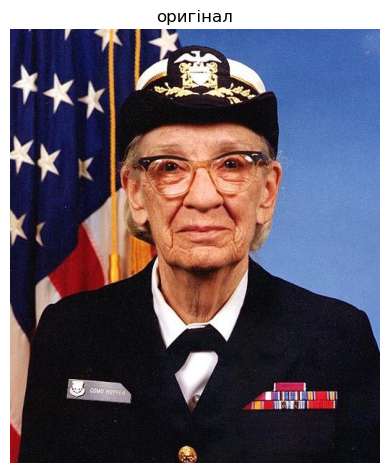

In [3]:
# Крок 2. Функція display_image
# Проста функція, щоб показати зображення через matplotlib. Прибираємо осі (для картинки вони зайві)
# і додаємо заголовок. Далі користуватимемось нею скрізь, щоб не повторювати той самий код.
def display_image(img, title=""):
    plt.figure(figsize=(4, 5))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

display_image(image, "оригінал")

In [4]:
# Маленький помічник, щоб показувати кілька зображень поруч (згодиться в кількох наступних кроках).
# Приймає список пар (заголовок, зображення). Для чорно-білих (2 виміри) вмикаємо сіру палітру.
def show_grid(pairs, cols=3):
    rows = (len(pairs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.4))
    axes = np.ravel(axes)
    for ax, (title, img) in zip(axes, pairs):
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    for ax in axes[len(pairs):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

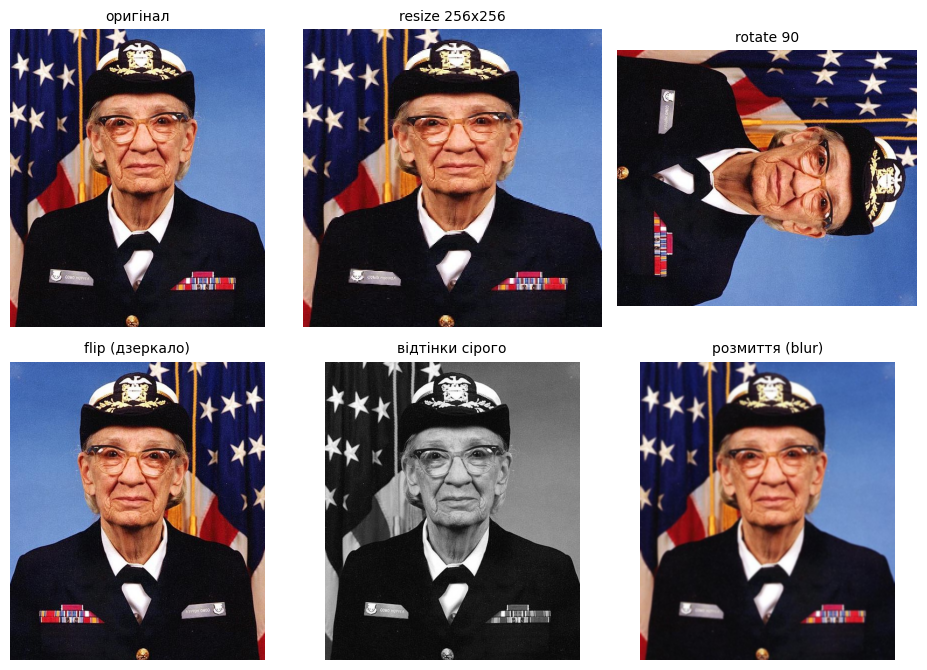

In [5]:
# Крок 3. Базова обробка зображень через OpenCV
# Кілька простих операцій: зміна розміру, поворот на 90 градусів, дзеркальне відбиття, переведення у
# відтінки сірого і розмиття. Показуємо їх поруч з оригіналом, щоб побачити ефект кожної.
resized = cv2.resize(image, (256, 256))
rotated = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
flipped = cv2.flip(image, 1)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(image, (7, 7), 0)

show_grid([
    ("оригінал", image),
    (f"resize {resized.shape[1]}x{resized.shape[0]}", resized),
    ("rotate 90", rotated),
    ("flip (дзеркало)", flipped),
    ("відтінки сірого", gray),
    ("розмиття (blur)", blurred),
])

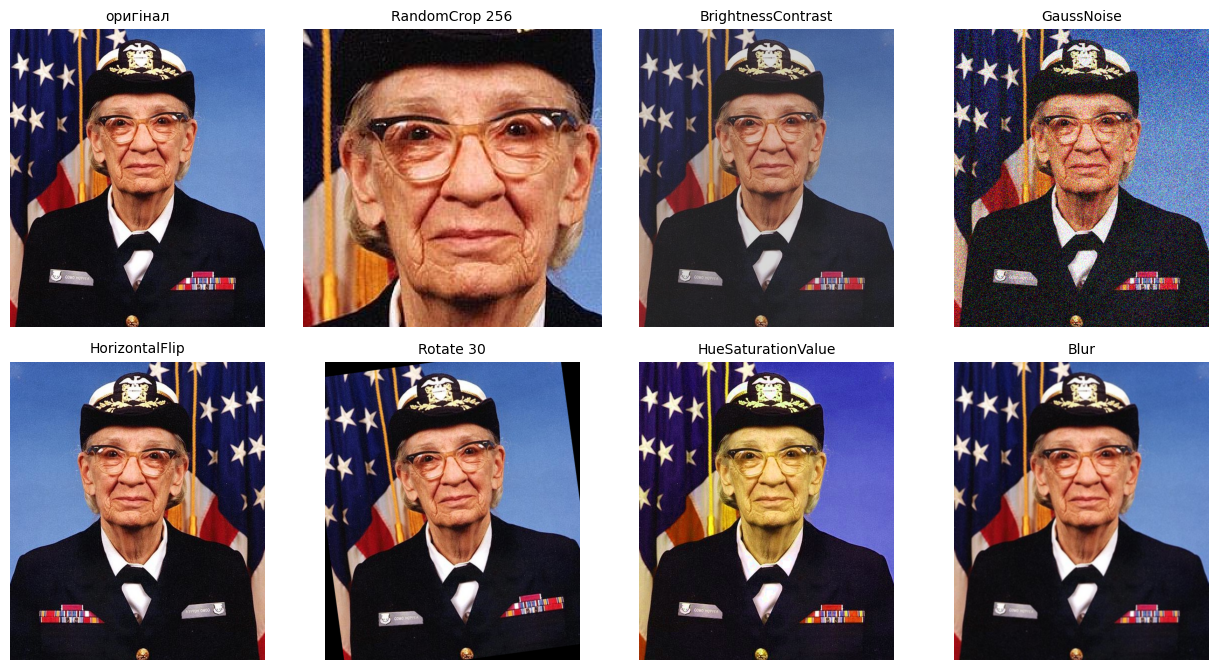

In [6]:
# Крок 4. Аугментації через Albumentations
# Albumentations застосовує випадкові трансформації - щоразу результат трохи інший. Показуємо ефект
# кожної окремо (p=1.0 означає, що трансформація точно застосується). Далі зберемо їх у один
# конвеєр.
augs = [
    ("RandomCrop 256", A.RandomCrop(height=256, width=256, p=1.0)),
    ("BrightnessContrast", A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0)),
    ("GaussNoise", A.GaussNoise(std_range=(0.1, 0.2), p=1.0)),
    ("HorizontalFlip", A.HorizontalFlip(p=1.0)),
    ("Rotate 30", A.Rotate(limit=30, p=1.0)),
    ("HueSaturationValue", A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30,
                                                val_shift_limit=20, p=1.0)),
    ("Blur", A.Blur(blur_limit=7, p=1.0)),
]
pairs = [("оригінал", image)] + [(name, t(image=image)["image"]) for name, t in augs]
show_grid(pairs, cols=4)

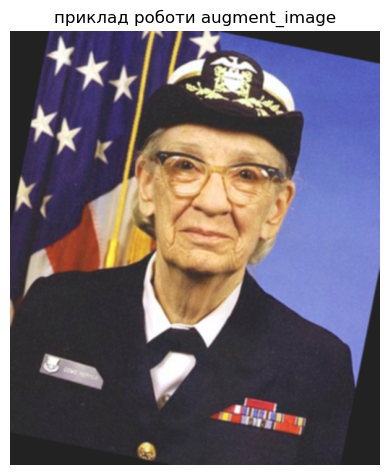

In [7]:
# Крок 5. Функція augment_image
# Збираємо кілька аугментацій в один конвеєр через A.Compose. У кожної своя ймовірність p, тобто
# вона застосовується не завжди - тому на кожному виклику виходить різна комбінація. Функція приймає
# зображення і повертає аугментоване. Трансформації тут не міняють розмір, щоб зручно порівнювати з
# оригіналом.
augment_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=25, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.5),
    A.GaussNoise(std_range=(0.05, 0.12), p=0.4),
    A.Blur(blur_limit=5, p=0.3),
])

def augment_image(img):
    return augment_pipeline(image=img)["image"]

display_image(augment_image(image), "приклад роботи augment_image")

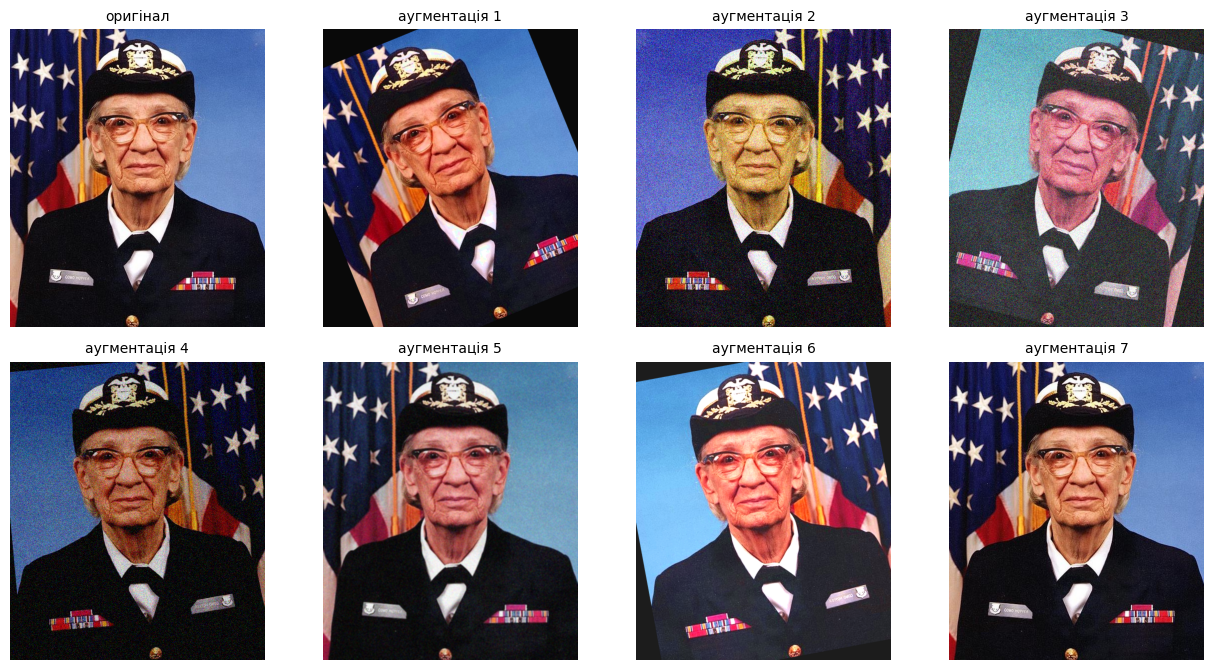

In [8]:
# Крок 6. Порівняння: оригінал vs аугментовані версії
# Викликаємо augment_image кілька разів на тому самому зображенні. Оскільки трансформації випадкові,
# щоразу виходить інша версія. Саме так з одного зображення роблять багато різних прикладів для
# навчання.
pairs = [("оригінал", image)] + [(f"аугментація {i + 1}", augment_image(image)) for i in range(7)]
show_grid(pairs, cols=4)

In [9]:
# Висновки
# - Зробили три функції: load_image (завантажує через OpenCV і виправляє порядок кольорів BGR->RGB),
#   display_image (показує через matplotlib) і augment_image (застосовує конвеєр аугментацій).
# - OpenCV дав базову обробку зображень: зміна розміру, поворот, дзеркало, відтінки сірого,
#   розмиття.
# - Albumentations дав випадкові аугментації: обрізання, зміна яскравості/контрасту, шум, поворот,
#   відбиття, зсув кольорів, розмиття. Їх зручно збирати в один конвеєр через A.Compose.
# - Головне про аугментацію: з одного зображення випадкові трансформації дають багато різних версій.
#   Так збільшують і урізноманітнюють дані, щоб модель краще узагальнювала.
# - Ці функції - готова основа, щоб підготувати зображення перед подачею в модель глибокого
#   навчання.